In this notebook we will import a model trained on the OpenDPD dataset and perform neural network pruning using a range of inverse models.

In [1]:
from sparseDPD import PGJANET_NeuralNetwork, PNTDNN_NeuralNetwork, ARVTDNN_NeuralNetwork
from sparseDPD import DataManager, Datapath, DatapathPruningExperiment

# load the OpenDPD dataset
# Same dataset/training style as refactored_notebook.ipynb
openDPD_folder = 'OpenDPD_datasets/DPA_160MHz'

#40,000 points
openDPD_dataManager = DataManager(
    num_test_points=98304,
    num_training_points=294912,
    num_validaiton_points=98304,
    openDPD_test_input_file=f'{openDPD_folder}/test_input.csv',
    openDPD_test_output_file=f'{openDPD_folder}/test_output.csv',
    openDPD_training_input_file=f'{openDPD_folder}/train_input.csv',
    openDPD_training_output_file=f'{openDPD_folder}/train_output.csv',
    openDPD_validation_input_file=f'{openDPD_folder}/val_input.csv',
    openDPD_validation_output_file=f'{openDPD_folder}/val_output.csv'
)

# Load forward model
PNTDNN_three_layer_forward_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='open_dpd_DPA_160MHz_forward_models/pntdnn_three_layer_open.pt')


Using cuda device


# PNTDNN one layer

Using cuda device
Epoch  10/50  Loss=1.2468e+00  Valid Loss=9.2807e+02  LR=1.00e-03
Epoch  20/50  Loss=9.0921e-01  Valid Loss=6.6401e+02  LR=1.00e-03
Epoch  30/50  Loss=6.6780e-01  Valid Loss=4.8298e+02  LR=1.00e-03
Epoch  40/50  Loss=5.3686e-01  Valid Loss=4.3445e+02  LR=1.00e-03
Epoch  50/50  Loss=5.0405e-01  Valid Loss=4.0189e+02  LR=1.00e-03

Best model from epoch 50 with validation loss: 4.0189e+02
Iteration 1/20 (Block 1/18, samples 0-16384) - NMSE: -3.5885 dB
Epoch  10/50  Loss=1.7323e-01  Valid Loss=1.2402e+03  LR=1.00e-03
Epoch  20/50  Loss=1.4406e-01  Valid Loss=1.1997e+03  LR=5.00e-04
Epoch  30/50  Loss=1.3615e-01  Valid Loss=1.1784e+03  LR=2.50e-04
Epoch  40/50  Loss=1.3262e-01  Valid Loss=1.1805e+03  LR=1.25e-04
Epoch  50/50  Loss=1.3052e-01  Valid Loss=1.1894e+03  LR=6.25e-05

Best model from epoch 1 with validation loss: 5.7453e+02
Iteration 2/20 (Block 2/18, samples 16384-32768) - NMSE: -6.8627 dB
Epoch  10/50  Loss=1.1820e-01  Valid Loss=1.5719e+03  LR=1.00e-03
Epoch  

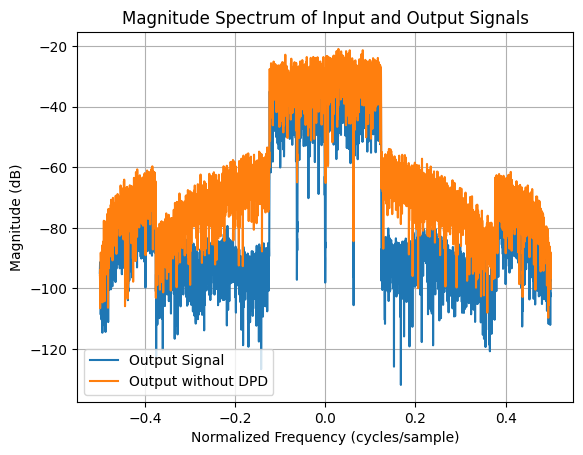

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_inverse_nn)

datapath_pntdnn_one_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 20,
    retrain_epochs_per_iteration=50,
    seq_length=16384
)

# find nmse
nmse = datapath_pntdnn_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_one_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

In [12]:
# Save inverse model
PNTDNN_inverse_nn.write_nn_to_file('pntdnn_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


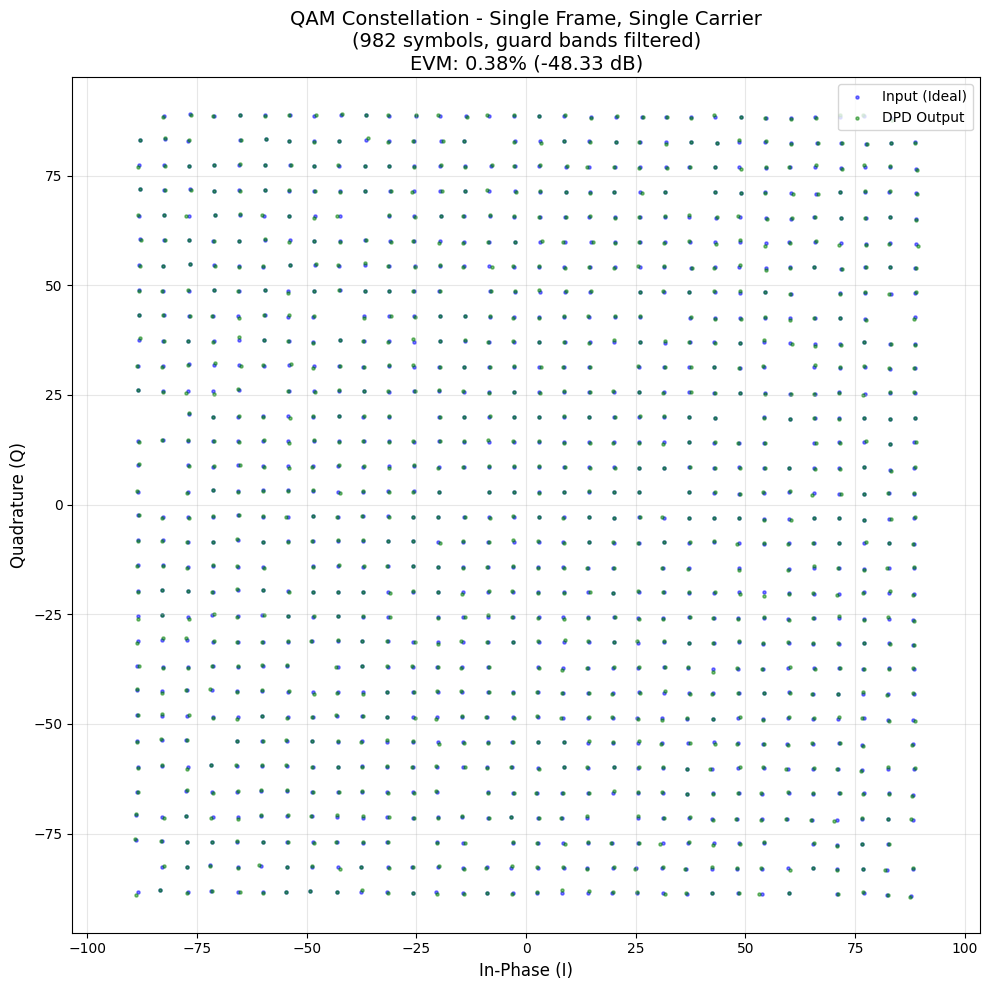

EVM (RMS): 0.383%
EVM (dB): -48.328 dB


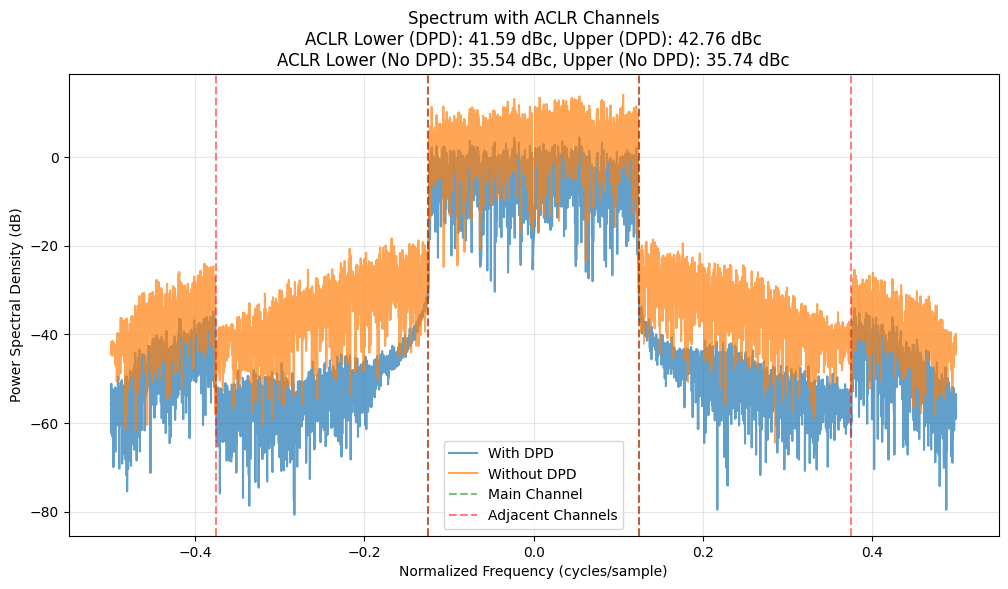

NMSE: (No DPD) 5.7197 dB


In [2]:
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pntdnn_one_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pntdnn_one_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=20,
    ila_iterations=3,
    nmse_tolerance=1,
    seq_length=16384
)

pruning_experiment_pntdnn_one_layer.run()


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 20 epochs...
Epoch  10/20  Loss=3.9009e-02  Valid Loss=1.0859e+02  LR=1.00e-03
Epoch  20/20  Loss=3.5684e-02  Valid Loss=9.6539e+01  LR=1.00e-03

Best model from epoch 20 with validation loss: 9.6539e+01
Iteration 1/3 (Block 1/1, samples 0-294912) - NMSE: -48.2583 dB


KeyboardInterrupt: 